In [1]:
!pip install nltk

In [2]:
!pip install tensorflow

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [5]:
import pandas as pd

sentences = pd.read_csv("/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/baseline-dataset/label_train.csv")
sentences['semantic_level'] = sentences['semantic_level'].apply(lambda x: [f"L{x}"])
sentences

,semantic_level,sentence
0,[L1],A bar chart entitled “Mean of Temperature Maxi...
1,[L1],The Mean of temp_max is plotted on the vertica...
2,[L1],The weather type is plotted on the horizontal ...
3,[L1],There are 5 bars corresponding to 5 precipitat...
4,[L1],The bars are solid blue.
...,...,...
2142,[L2],The continent with the highest amount of both ...
2143,[L2],Bolivia is the country with the lowest amount ...
2144,[L3],"A big part of Africa doesn't have many tests, ..."
2145,[L3],"In most cases, there is a strong positive corr..."


# Splitting for train and test

In [6]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit


split = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)

for train_index, sample_index in split.split(sentences, sentences['semantic_level']):
    test_sentences = sentences.iloc[sample_index]


train_sentences = sentences.drop(test_sentences.index)


print(train_sentences.shape)
print(test_sentences.shape)

(1932, 2)
(215, 2)


In [7]:
from transformers import BertTokenizer


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def encode_texts(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

# Tokenize Data
tokenized_data = encode_texts(train_sentences["sentence"].tolist())
input_ids = tokenized_data["input_ids"]
attention_mask = tokenized_data["attention_mask"]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [8]:
from sklearn.preprocessing import MultiLabelBinarizer
import torch

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(train_sentences["semantic_level"])
labels_tensor  = torch.tensor(labels, dtype=torch.float)

In [9]:
import torch.nn as nn
from transformers import BertModel

class BiLSTMWithBERT(nn.Module):
    def __init__(self, hidden_dim, num_labels, unfreeze_last=2):
        super(BiLSTMWithBERT, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for name, param in self.bert.named_parameters():
            param.requires_grad = False
            for layer_idx in range(12 - unfreeze_last, 12):
                if f"encoder.layer.{layer_idx}" in name or "pooler" in name:
                    param.requires_grad = True

        self.lstm    = nn.LSTM(
            input_size  = 768,
            hidden_size = hidden_dim,
            bidirectional= True,
            batch_first = True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        dropped = self.dropout(pooled)
        logits  = self.fc(dropped)
        return logits


In [10]:
import numpy as np

class EarlyStopping:
    """Stops training when validation loss hasn’t improved for `patience` epochs."""
    def __init__(self, patience=3, min_delta=0.0, path="checkpoint.pth"):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            min_delta (float): Minimum change to qualify as an improvement.
            path (str): Where to save the best model.
        """
        self.patience  = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter   = 0
        self.path      = path

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            # Improvement!
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True  # signal to stop
        return False

In [11]:
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR



dataset = TensorDataset(input_ids, attention_mask, labels_tensor)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

hidden_dim = 128
output_dim = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTMWithBERT(hidden_dim, output_dim).to(device)


class_counts = train_sentences["semantic_level"].value_counts().sort_index().tolist()
class_weights = torch.tensor([sum(class_counts) / c for c in class_counts], dtype=torch.float)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)
early_stopper = EarlyStopping(patience=5, min_delta=1e-4,
                              path="best_model.pth")

for epoch in range(100):
    model.train()
    total_loss = 0
    for input_ids, attention_mask, label_batch in train_loader:
        input_ids, attention_mask, label_batch = (
            input_ids.to(device),
            attention_mask.to(device),
            label_batch.to(device)
        )
        optimizer.zero_grad()
        output = model(input_ids, attention_mask)
        loss = criterion(output, label_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader)}")

    if early_stopper(total_loss, model):
        print(f"Stopping early at epoch {epoch} (no improvement for {early_stopper.patience} epochs).")
        break


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1, Loss: 0.5028670617371551
Epoch 2, Loss: 0.3488847772198275
Epoch 3, Loss: 0.284934759632615
Epoch 4, Loss: 0.24433029141307863
Epoch 5, Loss: 0.21871313280310511
Epoch 6, Loss: 0.20063726751764943
Epoch 7, Loss: 0.18256340717727487
Epoch 8, Loss: 0.17348221917290332
Epoch 9, Loss: 0.16996714035587862
Epoch 10, Loss: 0.1557400449494685
Epoch 11, Loss: 0.1545574633050556
Epoch 12, Loss: 0.1501919375347697
Epoch 13, Loss: 0.14877859583078337
Epoch 14, Loss: 0.14273830527855344
Epoch 15, Loss: 0.14315192940190805
Epoch 16, Loss: 0.13858484932460075
Epoch 17, Loss: 0.13643809706588422
Epoch 18, Loss: 0.13465368365945896
Epoch 19, Loss: 0.13694927887606226
Epoch 20, Loss: 0.1328899378249468
Epoch 21, Loss: 0.1328256764133607
Epoch 22, Loss: 0.13605993481214382
Epoch 23, Loss: 0.1345681423736998
Epoch 24, Loss: 0.13566470410951897
Epoch 25, Loss: 0.13335570403613334
Epoch 26, Loss: 0.13101822818236902
Epoch 27, Loss: 0.13649844692265692
Epoch 28, Loss: 0.13361407631684927
Epoch 29, L

# Evaluation

Hamming loss: 0.0930
Hamming accuracy: 0.9070

Classification report (per label):


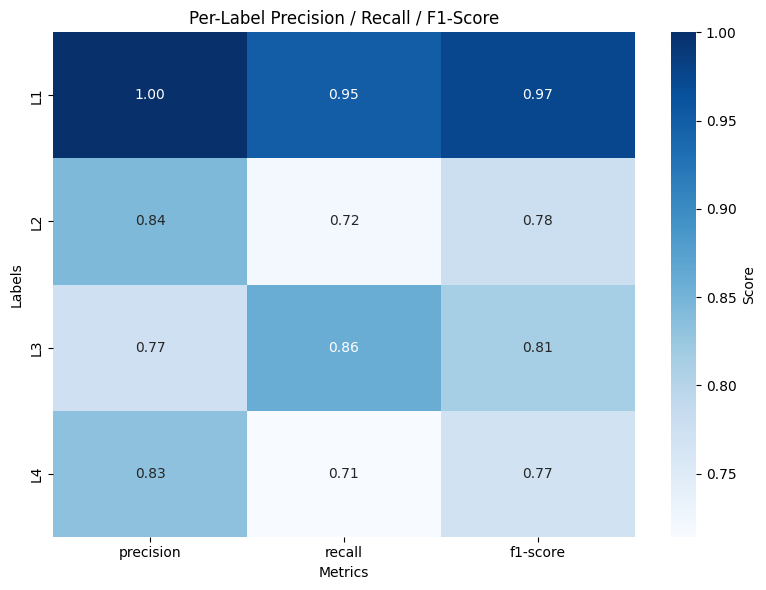

            micro avg   macro avg  weighted avg  samples avg
precision    0.822967    0.862898      0.827300     0.797674
recall       0.800000    0.810745      0.800000     0.800000
f1-score     0.811321    0.833750      0.810357     0.798450
support    215.000000  215.000000    215.000000   215.000000


In [14]:
from sklearn.metrics import (
    hamming_loss,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


test_tokenized = encode_texts(test_sentences["sentence"].tolist())
test_input_ids = test_tokenized["input_ids"]
test_attention_mask = test_tokenized["attention_mask"]
label_tensors = torch.tensor(mlb.transform(test_sentences["semantic_level"]), dtype=torch.long)

dataset = TensorDataset(test_input_ids, test_attention_mask, label_tensors)
val_loader = DataLoader(dataset, batch_size=16, shuffle=True)

model.eval()
val_correct = 0
val_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, label_batch in val_loader:
        input_ids, attention_mask, label_batch = (
            input_ids.to(device),
            attention_mask.to(device),
            label_batch.to(device)
        )

    logits = model(test_input_ids.to(device), test_attention_mask.to(device))
    probs  = torch.sigmoid(logits).cpu().numpy()

y_true = label_tensors.numpy()
threshold = 0.5
y_pred = (probs >= threshold).astype(int)


ham_loss = hamming_loss(y_true, y_pred)
print(f"Hamming loss: {ham_loss:.4f}")
print(f"Hamming accuracy: {1 - ham_loss:.4f}")

target_names = [str(c) for c in mlb.classes_]
print("\nClassification report (per label):")
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=[str(c) for c in mlb.classes_],
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report_dict).T

df_plot = df_report.drop(index=['micro avg', 'macro avg', 'weighted avg', 'samples avg'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_plot.iloc[:, :3],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={'label': 'Score'}
)
plt.title("Per-Label Precision / Recall / F1-Score")
plt.ylabel("Labels")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

print(df_report.T[['micro avg', 'macro avg', 'weighted avg', 'samples avg']])

In [15]:
checkpoint = {
    "hidden_dim":      hidden_dim,
    "num_labels":      output_dim,
    "unfreeze_last":   2,
    "mlb_classes":     mlb.classes_.tolist(),
    "tokenizer_name":  "bert-base-uncased",
    "model_state":     model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "epoch":           epoch,
}
torch.save(checkpoint, '/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm.pth')
tokenizer.save_pretrained("/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm/checkpoint/tokenizer/")

('/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm/checkpoint/tokenizer/tokenizer_config.json',
 '/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm/checkpoint/tokenizer/special_tokens_map.json',
 '/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm/checkpoint/tokenizer/vocab.txt',
 '/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm/checkpoint/tokenizer/added_tokens.json')

ckpt = torch.load("bilstm_bert_checkpoint.pth", map_location="cpu")

# 1) Rebuild the tokenizer
from transformers import BertTokenizerFast
tokenizer = BertTokenizerFast.from_pretrained("checkpoint/tokenizer/")

# 2) Recreate your MultiLabelBinarizer
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
mlb.classes_ = ckpt["mlb_classes"]

# 3) Reconstruct the model
model = BiLSTMWithBERT(
    hidden_dim    = ckpt["hidden_dim"],
    num_labels    = ckpt["num_labels"],
    unfreeze_last = ckpt["unfreeze_last"]
)
model.load_state_dict(ckpt["model_state"])

# 4) (If you want to resume training) recreate optimizer & scheduler, then load their states
optimizer.load_state_dict(ckpt["optimizer_state"])
scheduler.load_state_dict(ckpt["scheduler_state"])

# 5) Move to device & set eval/train as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
